# Análisis de Préstamos Hipotecarios con Machine Learning
## Interpretabilidad de modelos, consideraciones éticas y clustering

---

**Asignatura:** Análisis de datos en el ecosistema Python  
**Dataset:** HMDA (Home Mortgage Disclosure Act) - Utah 2022  
**Repositorio:** hmda-loan-approval-ml-analysis

---

Este notebook realiza un análisis completo de datos de préstamos hipotecarios utilizando técnicas de machine learning, con especial énfasis en:

- 📊 **Evaluación de modelos**: métricas de rendimiento y matriz de confusión
- 🔍 **Interpretabilidad**: SHAP, LIME e importancia de variables
- ⚖️ **Ética y fairness**: detección de sesgos y análisis de equidad en las decisiones de concesión de hipotecas
- 🧩 **Clustering**: segmentación de solicitantes y detección de perfiles atípicos

## 1. Introducción al proyecto

### 1.1 ¿Qué es el dataset HMDA?

El **Home Mortgage Disclosure Act (HMDA)** es una ley federal de Estados Unidos que requiere que las instituciones financieras reporten públicamente datos sobre préstamos hipotecarios. Esta información permite:

- Determinar si las instituciones financieras están atendiendo las necesidades de vivienda de sus comunidades
- Ayudar a los funcionarios públicos a distribuir inversiones del sector público
- Identificar posibles patrones de discriminación en la concesión de préstamos

Los datos HMDA incluyen información detallada sobre cada solicitud de préstamo hipotecario, incluyendo:
- Características del préstamo (monto, tipo, propósito)
- Características del solicitante (ingresos, raza, sexo, edad)
- Información geográfica
- Resultado de la solicitud (aprobada, denegada, etc.)

### 1.2 ¿Por qué Utah 2022?

Para este proyecto se ha seleccionado el subconjunto de datos correspondiente al estado de **Utah** del año **2022** por las siguientes razones:

1. **Viabilidad computacional**: el dataset nacional completo contiene millones de registros. El subconjunto de Utah ofrece un tamaño manejable para análisis sin comprometer la representatividad.
2. **Datos recientes**: los datos de 2022 reflejan prácticas actuales de concesión de préstamos.
3. **Enfoque de estudio de caso**: permite un análisis profundo de un mercado hipotecario específico, facilitando interpretaciones contextualizadas.

### 1.3 Objetivos del proyecto

Los objetivos concretos de este proyecto son:

1. **Definir y construir el target**: convertir `action_taken` en una variable binaria (aprobado/denegado) y justificar la codificación usada.
2. **Comparar rendimiento de modelos**: entrenar Regresión Logística, Random Forest y Gradient Boosting y comparar **AUC, F1, recall y matriz de confusión** para seleccionar el mejor modelo.
3. **Identificar variables más influyentes**: extraer e interpretar las 10 características con mayor impacto usando **feature importance y SHAP**.
4. **Evaluar sesgos por subgrupos**: medir diferencias de tasas de aprobación y métricas del modelo por **raza, sexo y edad**, y cuantificar brechas.
5. **Analizar patrones no supervisados**: aplicar **K-Means y DBSCAN** para descubrir perfiles de solicitantes y relacionarlos con la aprobación.
6. **Extraer conclusiones accionables**: sintetizar hallazgos sobre desempeño, interpretabilidad y equidad para recomendaciones finales.

## 2. Descripción del conjunto de datos

### 2.1 Origen de los datos

Los datos utilizados en este proyecto provienen del **Consumer Financial Protection Bureau (CFPB)**, que administra la recopilación y publicación de datos bajo el HMDA. El dataset específico ha sido obtenido de Kaggle:

📁 **Fuente**: [Utah HMDA Data 2018-2022](https://www.kaggle.com/datasets/richcordova/utah-hmda-data-2018-2022/data?select=utah_hmda_data_2022.csv)

### 2.2 Estructura general del dataset

El dataset de Utah 2022 contiene información sobre solicitudes de préstamos hipotecarios procesadas por instituciones financieras en el estado de Utah durante el año 2022. Cada fila representa una solicitud de préstamo individual.

### 2.3 Variables principales

| Variable | Descripción | Tipo |
|----------|-------------|------|
| `action_taken` | Resultado de la solicitud (aprobada, denegada, retirada, etc.) | Categórica (Target) |
| `loan_amount` | Monto del préstamo solicitado | Numérica |
| `income` | Ingresos anuales del solicitante (en miles de dólares) | Numérica |
| `loan_to_value_ratio` | Ratio préstamo-valor de la propiedad | Numérica |
| `debt_to_income_ratio` | Ratio deuda-ingresos del solicitante | Categórica/Numérica |
| `property_value` | Valor estimado de la propiedad | Numérica |
| `loan_type` | Tipo de préstamo (convencional, FHA, VA, etc.) | Categórica |
| `loan_purpose` | Propósito del préstamo (compra, refinanciamiento, etc.) | Categórica |
| `occupancy_type` | Tipo de ocupación de la propiedad | Categórica |
| `derived_race` | Raza del solicitante principal | Categórica (Sensible) |
| `derived_sex` | Sexo del solicitante principal | Categórica (Sensible) |
| `applicant_age` | Edad del solicitante | Categórica (Sensible) |
| `county_code` | Código del condado | Categórica |

### 2.4 Atributos sensibles para el análisis ético

⚠️ **Atributos sensibles identificados:**

Los siguientes atributos se consideran **sensibles** desde una perspectiva ética y legal, ya que están protegidos bajo leyes de no discriminación:

- **`derived_race`**: raza/etnicidad del solicitante
- **`derived_sex`**: sexo/género del solicitante  
- **`applicant_age`**: edad del solicitante

Estos atributos serán analizados específicamente en la sección de análisis ético para detectar posibles sesgos en las predicciones del modelo.

## 3. Distribución del trabajo

### 👤 Robert: preprocesamiento y modelado

**Responsabilidades:**
- Carga y limpieza inicial de los datos
- Análisis exploratorio de datos (EDA)
- Construcción de pipelines de preprocesamiento
- Selección y codificación de variables

**Secciones del notebook:** 4, 5

---

### 👤 Rodrigo: interpretabilidad de modelos

**Responsabilidades:**
- Entrenamiento de modelos de machine learning
- Evaluación inicial mediante métricas de rendimiento
- Implementación de análisis SHAP (SHapley Additive exPlanations)
- Implementación de explicaciones LIME (Local Interpretable Model-agnostic Explanations)
- Análisis de importancia de variables
- Interpretación del comportamiento global y local del modelo
- Visualización de explicaciones

**Secciones del notebook:** 6, 7, 8

---

### 👤 Juan: análisis ético y detección de sesgos

**Responsabilidades:**
- Análisis de rendimiento por subgrupos (fairness)
- Detección de sesgos en datos y predicciones
- Comparación de métricas entre grupos sensibles
- Discusión crítica de implicaciones éticas
- Redacción de conclusiones y recomendaciones

**Secciones del notebook:** 9

### 🫂 Conjunto: análisis de clustering (segmentación de solicitantes)

**Responsabilidades:**
- Preparación de los datos para aprendizaje no supervisado
- Implementación de K-Means con Método del Codo y Silhouette Score
- Implementación de DBSCAN para detección de solicitudes atípicas
- Clustering Jerárquico y comparativa de algoritmos
- Perfilado e interpretación de los clusters descubiertos
- Análisis de la relación entre clusters y decisiones de aprobación
- Estudio de la distribución demográfica por cluster (dimensión ética)

**Secciones del notebook:** 10

---

## 4. Carga de datos y exploración inicial

### 4.1 Configuración del entorno

Primero importamos todas las librerías necesarias para el análisis.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

### 4.2 Carga del dataset

Cargamos el dataset de Utah HMDA 2022 desde la carpeta `data/`.

In [2]:
# Carga del dataset HMDA Utah 2022
df = pd.read_csv('data/utah_hmda_data_2022.csv')

# Guardar una copia del DataFrame original para no sobrescribir los datos originales
df_original = df.copy()

# Visualizamos las primeras filas para comprobar la carga
df.head()

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason-2,denial_reason-3,denial_reason-4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2022,5493000YNV8IX4VD3X12,41620,UT,49035.0,4.903511e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Hispanic or Latino,...,2.0,NaN,NaN,7413,72.99,102200,69,1314,1802,43
1,2022,5493000YNV8IX4VD3X12,36260,UT,49011.0,4.901113e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Not Hispanic or Latino,...,6.0,NaN,NaN,5555,32.24,99600,90,1378,1740,39
2,2022,5493000YNV8IX4VD3X12,41620,UT,49035.0,4.903511e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Hispanic or Latino,...,7.0,NaN,NaN,5951,57.82,102200,93,1372,1400,18
3,2022,5493000YNV8IX4VD3X12,41620,UT,49035.0,4.903511e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Ethnicity Not Available,...,NaN,NaN,NaN,7413,72.99,102200,69,1314,1802,43
4,2022,5493000YNV8IX4VD3X12,36260,UT,49057.0,4.905721e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Joint,...,NaN,NaN,NaN,5165,27.42,99600,70,1162,1449,42


### 4.3 Exploración inicial del dataset

Examinamos la estructura básica del dataset: primeras filas, tipos de datos e información general.

In [3]:
# Visualizar las primeras 10 filas del dataset
df.head(10)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason-2,denial_reason-3,denial_reason-4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2022,5493000YNV8IX4VD3X12,41620,UT,49035.0,4.903511e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Hispanic or Latino,...,2.0,NaN,NaN,7413,72.99,102200,69,1314,1802,43
1,2022,5493000YNV8IX4VD3X12,36260,UT,49011.0,4.901113e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Not Hispanic or Latino,...,6.0,NaN,NaN,5555,32.24,99600,90,1378,1740,39
2,2022,5493000YNV8IX4VD3X12,41620,UT,49035.0,4.903511e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Hispanic or Latino,...,7.0,NaN,NaN,5951,57.82,102200,93,1372,1400,18
3,2022,5493000YNV8IX4VD3X12,41620,UT,49035.0,4.903511e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Ethnicity Not Available,...,NaN,NaN,NaN,7413,72.99,102200,69,1314,1802,43
4,2022,5493000YNV8IX4VD3X12,36260,UT,49057.0,4.905721e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Joint,...,NaN,NaN,NaN,5165,27.42,99600,70,1162,1449,42
5,2022,5493000YNV8IX4VD3X12,39340,UT,49049.0,4.904900e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Hispanic or Latino,...,7.0,NaN,NaN,4218,37.53,96000,50,433,1162,50
6,2022,5493000YNV8IX4VD3X12,99999,UT,49037.0,4.903798e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Not Hispanic or Latino,...,NaN,NaN,NaN,3562,18.22,83200,89,1099,1618,43
7,2022,5493000YNV8IX4VD3X12,41620,UT,49035.0,4.903511e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Not Hispanic or Latino,...,NaN,NaN,NaN,5951,57.82,102200,93,1372,1400,18
8,2022,5493000YNV8IX4VD3X12,41620,UT,49035.0,4.903511e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Ethnicity Not Available,...,2.0,NaN,NaN,6168,28.31,102200,83,1660,1968,34
9,2022,5493000YNV8IX4VD3X12,99999,UT,49037.0,4.903794e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Ethnicity Not Available,...,NaN,NaN,NaN,2482,95.49,83200,33,570,908,33


In [4]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226790 entries, 0 to 226789
Data columns (total 99 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   activity_year                             226790 non-null  int64  
 1   lei                                       226790 non-null  object 
 2   derived_msa-md                            226790 non-null  int64  
 3   state_code                                226790 non-null  object 
 4   county_code                               224948 non-null  float64
 5   census_tract                              224050 non-null  float64
 6   conforming_loan_limit                     226471 non-null  object 
 7   derived_loan_product_type                 226790 non-null  object 
 8   derived_dwelling_category                 226790 non-null  object 
 9   derived_ethnicity                         226790 non-null  object 
 10  derived_race        

In [5]:
# Estadísticas descriptivas de variables numéricas
df.select_dtypes(include=['number']).describe().round(2)

,activity_year,derived_msa-md,county_code,census_tract,action_taken,purchaser_type,preapproval,loan_type,loan_purpose,lien_status,...,denial_reason-2,denial_reason-3,denial_reason-4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
count,226790.0,226790.00,224948.00,2.240500e+05,226790.00,226790.00,226790.00,226790.00,226790.00,226790.00,...,7754.00,1327.00,117.00,226790.00,226790.00,226790.00,226790.00,226790.00,226790.00,226790.00
mean,2022.0,45496.79,49037.16,4.903735e+10,2.28,4.46,1.99,1.19,12.51,1.29,...,4.15,4.88,6.19,5392.41,22.65,95344.41,106.71,1171.45,1508.84,28.55
std,0.0,19359.30,15.56,1.555367e+07,1.71,15.07,0.11,0.52,14.38,0.45,...,2.70,2.65,2.82,2165.09,13.09,11230.80,32.91,463.88,582.49,16.01
min,2022.0,0.00,49001.00,4.900110e+10,1.00,0.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2022.0,36260.00,49035.00,4.903510e+10,1.00,0.00,2.00,1.00,1.00,1.00,...,2.00,3.00,4.00,4017.00,13.95,96000.00,86.00,844.00,1109.00,16.00
50%,2022.0,41100.00,49035.00,4.903511e+10,1.00,0.00,2.00,1.00,2.00,1.00,...,4.00,4.00,6.00,5236.00,19.33,99600.00,104.00,1159.00,1493.00,26.00
75%,2022.0,41620.00,49049.00,4.904901e+10,4.00,2.00,2.00,1.00,31.00,2.00,...,6.00,6.00,9.00,6530.00,27.62,102200.00,124.00,1478.00,1832.00,41.00
max,2022.0,99999.00,49057.00,4.905721e+10,8.00,72.00,2.00,4.00,32.00,2.00,...,9.00,9.00,9.00,15965.00,99.05,102200.00,277.00,2677.00,4083.00,80.00


### 4.4 Análisis y eliminación de valores innecesarios

Primero vamos a realizar un análisis previo para confirmar qué columnas vamos a eliminar del dataset, ya sea por excesiva cantidad de nulos, identificadores irrelevantes, duplicados o que no aportan valor para el análisis.

In [145]:
# Lista donde almacenaremos las columnas a eliminar
columnas_a_eliminar = []
motivos_eliminacion = {}

# 1. Columnas con demasiados nulos
porcentaje_nulos = df.isnull().mean()

columnas_nulos = porcentaje_nulos[porcentaje_nulos > 0.6].index.tolist()

for col in columnas_nulos:
    columnas_a_eliminar.append(col)
    motivos_eliminacion[col] = "Más del 60% de valores nulos"

# 2. Columnas identificadoras (IDs)
columnas_id = [col for col in df.columns if 'id' in col.lower()]

for col in columnas_id:
    if col not in columnas_a_eliminar:
        columnas_a_eliminar.append(col)
        motivos_eliminacion[col] = "Columna identificadora sin valor analítico"

# 3. Columnas constantes o casi constantes
columnas_constantes = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]

for col in columnas_constantes:
    if col not in columnas_a_eliminar:
        columnas_a_eliminar.append(col)
        motivos_eliminacion[col] = "Columna constante o sin variabilidad"

# 4. Columnas duplicadas
columnas_duplicadas = df.columns[df.T.duplicated()].tolist()

for col in columnas_duplicadas:
    if col not in columnas_a_eliminar:
        columnas_a_eliminar.append(col)
        motivos_eliminacion[col] = "Columna duplicada"

# Resultado final
print("Columnas a eliminar:")
for col in columnas_a_eliminar:
    print(f"- {col}: {motivos_eliminacion[col]}")

# Guardamos el dataframe limpio en un nuevo csv para futuras referencias
df_limpio = df_original.drop(columns=columnas_a_eliminar)

df_limpio.to_csv(
    'data/utah_hmda_data_2022_limpio.csv',
    index=False
)

Columnas a eliminar:
- total_points_and_fees: Más del 60% de valores nulos
- discount_points: Más del 60% de valores nulos
- lender_credits: Más del 60% de valores nulos
- prepayment_penalty_term: Más del 60% de valores nulos
- intro_rate_period: Más del 60% de valores nulos
- multifamily_affordable_units: Más del 60% de valores nulos
- applicant_ethnicity-2: Más del 60% de valores nulos
- applicant_ethnicity-3: Más del 60% de valores nulos
- applicant_ethnicity-4: Más del 60% de valores nulos
- applicant_ethnicity-5: Más del 60% de valores nulos
- co-applicant_ethnicity-2: Más del 60% de valores nulos
- co-applicant_ethnicity-3: Más del 60% de valores nulos
- co-applicant_ethnicity-4: Más del 60% de valores nulos
- co-applicant_ethnicity-5: Más del 60% de valores nulos
- applicant_race-2: Más del 60% de valores nulos
- applicant_race-3: Más del 60% de valores nulos
- applicant_race-4: Más del 60% de valores nulos
- applicant_race-5: Más del 60% de valores nulos
- co-applicant_race-2: 

#### ¿Por qué eliminamos estas columnas?

1. Columnas con >80% de valores nulos: no aportan información útil al análisis porque la mayoría de sus valores están ausentes.
2. Identificadores irrelevantes: columnas como 'lei' y 'census_tract' son identificadores únicos o geográficos que no contribuyen al modelado predictivo y pueden introducir ruido.
3. Columnas duplicadas o redundantes: algunas variables recogen la misma información que otras o son observaciones auxiliares (por ejemplo, variantes de etnia, raza o sexo del co-solicitante) que no se utilizarán en el análisis principal.
4. Variables que no aportan valor analítico: columnas que, tras el análisis exploratorio, se considera que no añaden información relevante para los objetivos del proyecto.

El objetivo actual es simplificar el dataset, reducir la dimensionalidad y evitar problemas de multicolinealidad o sobreajuste en los modelos posteriores.

In [146]:
# Mostramos las primeras filas del dataset tras eliminar las columnas seleccionadas
df_limpio.head()

,lei,derived_msa-md,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,derived_race,derived_sex,...,initially_payable_to_institution,aus-1,denial_reason-1,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,5493000YNV8IX4VD3X12,41620,49035.0,4.903511e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Hispanic or Latino,White,Female,...,1,6,1,7413,72.99,102200,69,1314,1802,43
1,5493000YNV8IX4VD3X12,36260,49011.0,4.901113e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Not Hispanic or Latino,White,Female,...,1,6,3,5555,32.24,99600,90,1378,1740,39
2,5493000YNV8IX4VD3X12,41620,49035.0,4.903511e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Hispanic or Latino,Race Not Available,Male,...,1,6,1,5951,57.82,102200,93,1372,1400,18
3,5493000YNV8IX4VD3X12,41620,49035.0,4.903511e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Ethnicity Not Available,Race Not Available,Joint,...,1,6,10,7413,72.99,102200,69,1314,1802,43
4,5493000YNV8IX4VD3X12,36260,49057.0,4.905721e+10,C,Conventional:First Lien,Single Family (1-4 Units):Manufactured,Joint,White,Joint,...,1,6,3,5165,27.42,99600,70,1162,1449,42


En conclusión, tras esta limpieza de columnas innecesarias hemos podido simplificar el dataset, reducir la dimensionalidad y con ello podemos evitar problemas de multicolinealidad o sobreajuste en los modelos posteriores.

### 4.5 Exploración de la variable objetivo

La variable `action_taken` indica el resultado de la solicitud de préstamo, y es la mejor variable objetivo. 
- Representa el evento a predecir
- No es una variable explicativa (es decir, es el resultado)
- Está disponible al final del proceso
- Es estándar en literatura y proyectos HMDA
- Permite múltiples enfoques (clasificacion binaria y multiclase)

Analizamos su distribución.

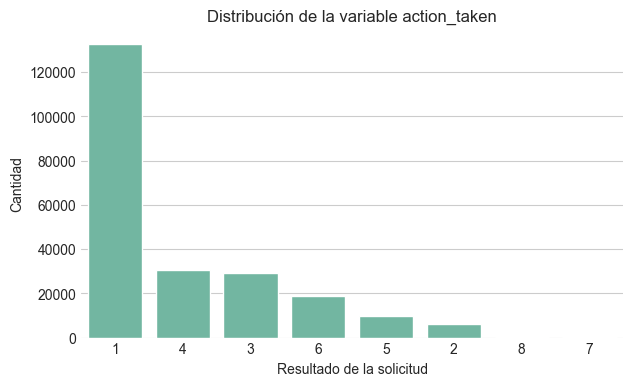

action_taken
1    132611
4     30344
3     29059
6     18763
5      9603
2      5952
8       340
7       118
Name: count, dtype: int64

action_taken
1    0.585
4    0.134
3    0.128
6    0.083
5    0.042
2    0.026
8    0.001
7    0.001
Name: proportion, dtype: float64

In [147]:
# Definición de la variable objetivo
variable_objetivo = 'action_taken'

# Análisis de la variable objetivo
plt.figure(figsize=(7,4))
sns.countplot(x=variable_objetivo, data=df_limpio, order=df_limpio[variable_objetivo].value_counts().index)
plt.title(f'Distribución de la variable {variable_objetivo}')
plt.xlabel('Resultado de la solicitud')
plt.ylabel('Cantidad')
plt.show()

# Mostrar recuento y proporción
display(df_limpio[variable_objetivo].value_counts())
display(df_limpio[variable_objetivo].value_counts(normalize=True).round(3))

Podemos ver que la variable objetivo `action_token`, que representa el resultado final de cada solicitud de préstamo hipotecario, refleja que la categoría 1 es la más frecuente. El resto de categorías (2, 3, 4, 5, 6) tienen frecuencias notablemente menores (algunas clases son residuales, 7 y 8). 

Esto es lo esperable en este dataset, donde la mayoría de solicitudes terminan en un resultado correcto (*loan originated*) y donde existen múltiples resultados alternativos con menor frecuencia. 

Es importante saber que aunque hay diferencias entre clases, no estamos ante un **desbalance extremo**.

#### 4.5.1. Exploración de la variable objetivo

In [148]:
# Distribución absoluta
dist_abs = df_limpio[variable_objetivo].value_counts()

# Distribución relativa
dist_rel = df_limpio[variable_objetivo].value_counts(normalize=True) * 100

df_dist = pd.DataFrame({
    "Frecuencia": dist_abs,
    "Porcentaje (%)": dist_rel.round(2)
})

df_dist

,Frecuencia,Porcentaje (%)
action_taken,,
1,132611,58.47
4,30344,13.38
3,29059,12.81
6,18763,8.27
5,9603,4.23
2,5952,2.62
8,340,0.15
7,118,0.05


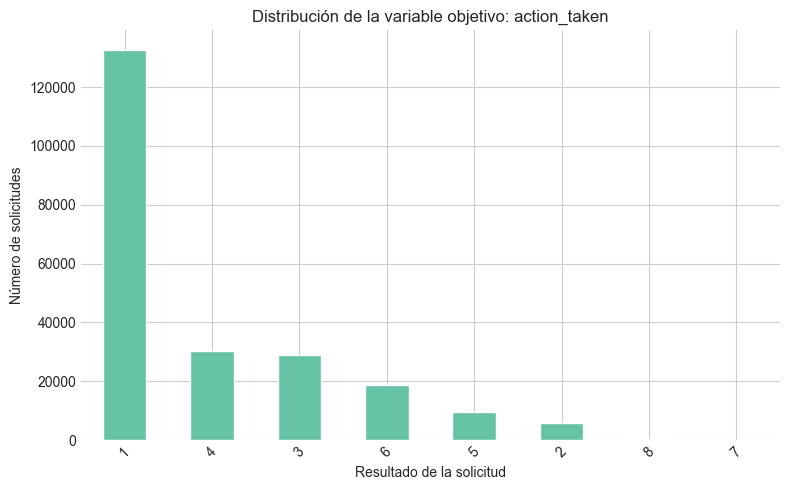

In [149]:
import matplotlib.pyplot as plt

# Visualización de la distribución absoluta
plt.figure(figsize=(8, 5))
dist_abs.plot(kind='bar')
plt.title('Distribución de la variable objetivo: action_taken')
plt.xlabel('Resultado de la solicitud')
plt.ylabel('Número de solicitudes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [150]:
# Análisis de desbalanceo
clase_mayoritaria = dist_rel.max()

print(
    f"La clase mayoritaria representa aproximadamente "
    f"el {clase_mayoritaria:.2f}% del total de observaciones."
)

La clase mayoritaria representa aproximadamente el 58.47% del total de observaciones.


Tras la exploración de la variable objetivo, podemos ver que estamos ante un dataset que no está completamente balanceado pero tampoco está severamente desbalanceado, totalmente aceptable para EDA y análisis exploratorio.

### 4.6 Exploración de variables clave

Visualizamos la distribución de algunas variables importantes para el análisis. 

En este caso vamos a explorar las siguientes variables `numéricas`:
- loan_amount
- interest_rate
- loan_term
- income
- debt_to_income_ratio
- property_value

Y, por supuesto, las siguientes variables `categóricas`:
- loan_type
- loan_purpose
- occupancy_type
- lien_status

In [281]:
variables_numericas_clave = [
    'loan_amount',
    'interest_rate',
    'loan_term',
    'income',
    'property_value'
]

df_limpio[variables_numericas_clave].describe()

,loan_amount,income
count,2.267900e+05,2.066040e+05
mean,4.573405e+05,1.589409e+02
std,5.005318e+07,4.905788e+03
min,5.000000e+03,-8.978000e+03
25%,1.250000e+05,6.900000e+01
50%,2.950000e+05,1.000000e+02
75%,4.350000e+05,1.500000e+02
max,2.380006e+10,2.190556e+06


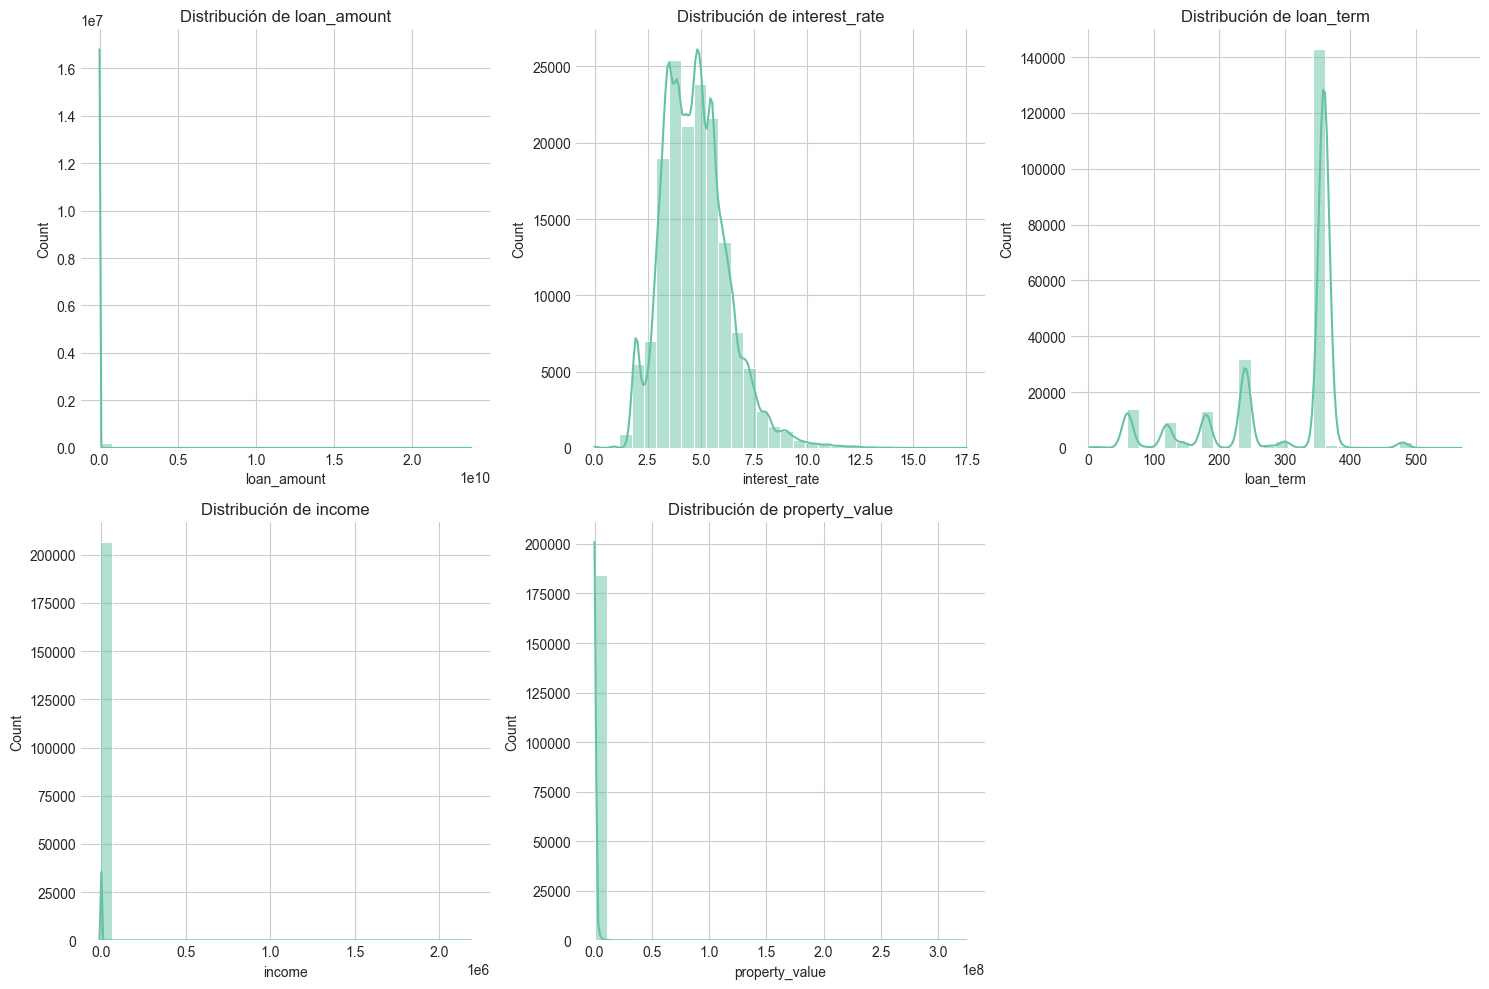

In [282]:
# Distribución de las variables numéricas clave
plt.figure(figsize=(15, 10))

for i, var in enumerate(variables_numericas_clave, 1):
    plt.subplot(2, 3, i)
    col_data = pd.to_numeric(df_limpio[var], errors='coerce') if df_limpio[var].dtype == 'object' else df_limpio[var]
    sns.histplot(col_data, bins=30, kde=True)
    plt.title(f'Distribución de {var}')

plt.tight_layout()
plt.show()

Tras la distribución de las variables numéricas clave, podemos sacar las siguientes observaciones generales:
- En `loan_amount`, podemos ver que hay una distribución muy sesgada a la derecha, donde la mayoría de los préstamos son de bajo montos, pero existen algunos valores extremadamente altos (posibles outliers o errores de carga).
- En `interest_rate`, podemos ver una distribución unimodal, donde la mayoría de las tasas se concentran entre un 3% y 7%. Hay también una cola derecha, donde existen tasas más altas, pero poco frecuentes.
- En `loan_term`, podemos observar que hay picos claros, donde la mayoría de los préstamos tienen plazos estándar (ej. 360 meses = 30 años). Hay otros valores que pueden ser otros plazos, pero son minoritarios.
- En `income`, podemos ver una distribución muy sesgada, donde la mayoría de los ingresos son bajos o moderados, pero hay valores extremadamente altos (outliers).
- En `property_value`, podemos ver una distribución similar a loan_amount e income, donde se concentra la mayoría de los valores bajos/moderados y algunos valores extremadamente altos por posibles outliers.

##### Conclusiones generales
Hemos podido observar que varias variables presentan valores extremos que pueden distorsionar el análisis y los modelos. Es recomendable analizar y posiblemente tratar estos outliers. Por último, antes de modelar, sería útil revisar los valores máximos y mínimos de cada variable para detectar errores de carga o codificación.

##### Para las variables categóricas:

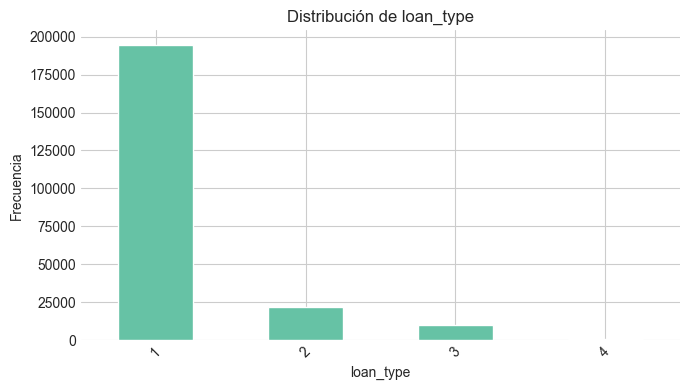

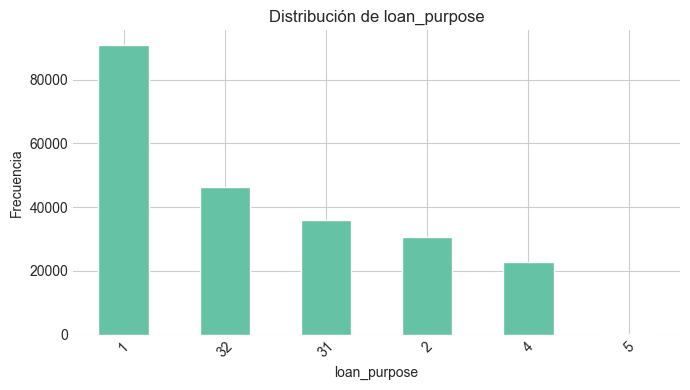

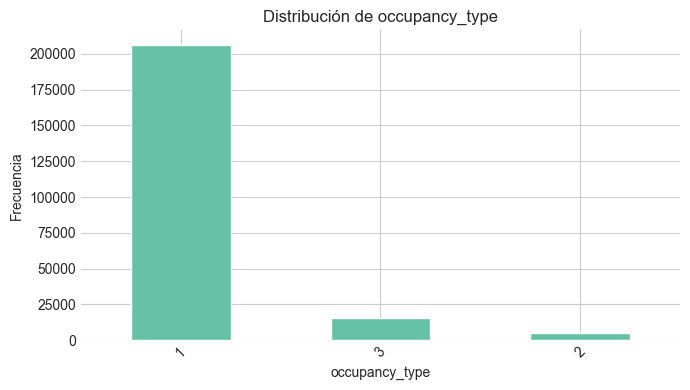

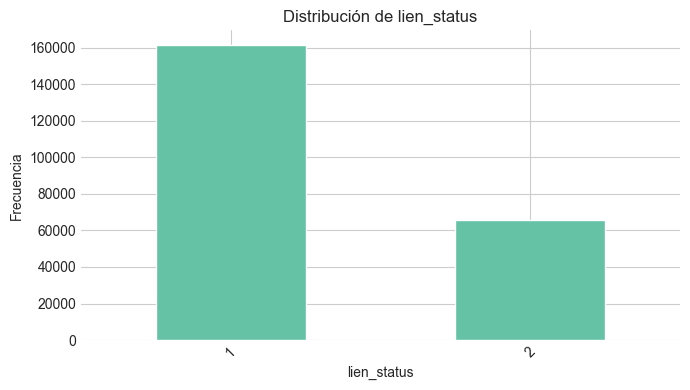

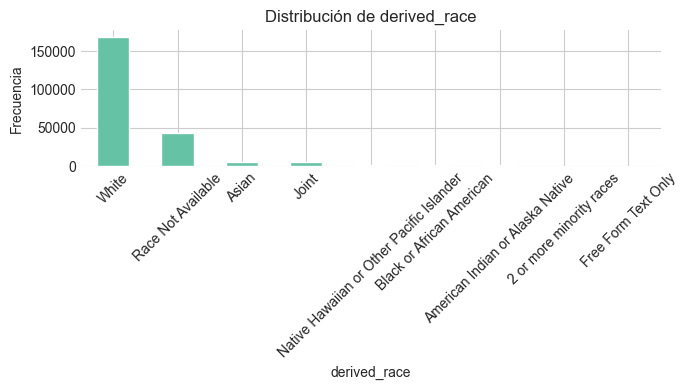

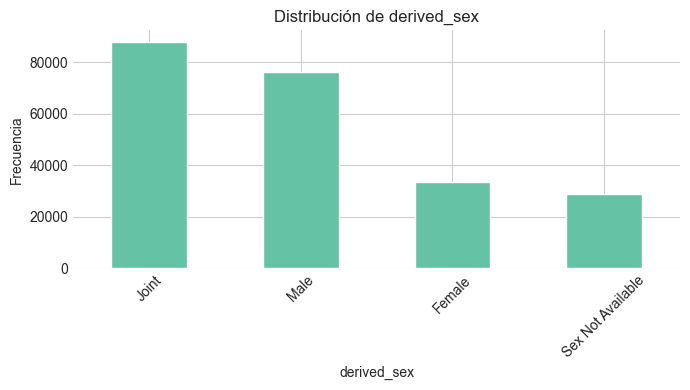

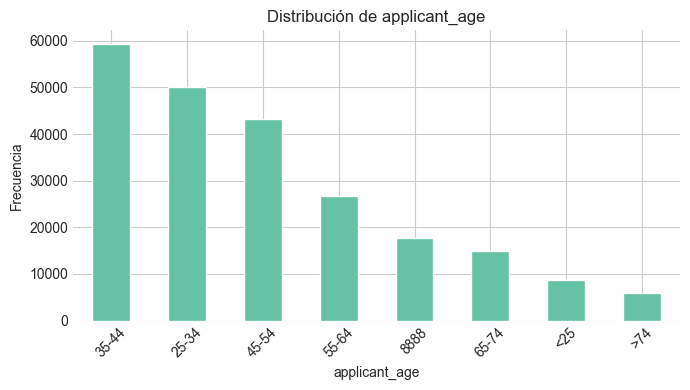

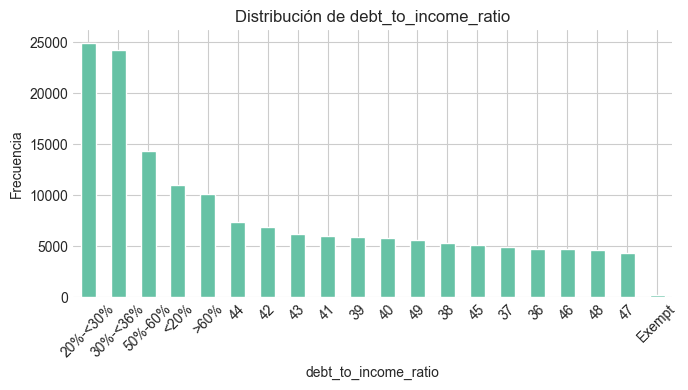

In [283]:
variables_categoricas_clave = [
    'loan_type',
    'loan_purpose',
    'occupancy_type',
    'lien_status',
    'derived_race',
    'derived_sex',
    'applicant_age',
    'debt_to_income_ratio'
]

for var in variables_categoricas_clave:
    plt.figure(figsize=(7, 4))
    df_limpio[var].value_counts().plot(kind='bar')
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Tras la distribución de las variables categóricas clave, podemos sacar las siguientes observaciones generales:
- En `loan_type`, podemos ver que la categoría 1 es la más frecuente, representando la mayoría de los préstamos (probablemente préstamos convencionales). Las categorías 2 y 3 tienen una presencia mucho menor, y la categoría 4 es residual o casi inexistente.
- En `loan_purpose`, la categoría 1 es la dominante (probablemente compra de vivienda), seguida por las categorías 32 y 31 (posiblemente refinanciamiento y cash-out refinance). El resto de categorías tienen frecuencias menores, algunas casi residuales.
- En `occupancy_type`, la categoría 1 es la más común (probablemente propietario ocupa la vivienda), mientras que las categorías 3 y 2 son mucho menos frecuentes, lo que indica que la mayoría de los préstamos son para viviendas ocupadas por el propietario.
- En `lien_status`, la categoría 1 es la más frecuente (primer gravamen), y la categoría 2 tiene una presencia mucho menor, lo que refleja que la mayoría de los préstamos hipotecarios son de primer gravamen.
- En `derived_race`, observamos que la categoría "White" es la más frecuente, representando la gran mayoría de los solicitantes. El resto de categorías (como "Asian", "Black or African American", "Native Hawaiian or Other Pacific Islander", etc.) tienen una presencia mucho menor, y algunas son prácticamente residuales. También destaca la categoría "Race Not Available", que tiene una frecuencia significativa, indicando registros donde no se reportó la raza.
- En `derived_sex`, la categoría "Joint" (solicitud conjunta) es la más común, seguida por "Male". "Female" tiene una frecuencia considerablemente menor, y "Sex Not Available" representa un grupo relevante de registros donde no se reportó el sexo del solicitante.
- En `applicant_age`, la categoría "35-44" es la más frecuente, seguida por "25-34" y "45-54". Las categorías de mayor edad ("65-74", ">74") y menor edad ("<25") tienen una presencia mucho menor, lo que indica que la mayoría de los solicitantes se encuentran en rangos de edad intermedia. También hay una categoría "8888" que podría representar valores faltantes o codificados de manera especial.
- En `debt_to_income_ratio`, las categorías más frecuentes son los intervalos '20%<30%' y '30%<36%', seguidos por '50%<60%', '<20%' y '>60%'. Los valores numéricos individuales como 44, 42, 41, etc., tienen una presencia mucho menor, lo que indica que la mayoría de los solicitantes se agrupan en rangos discretos de ratio deuda-ingresos. La categoría 'Exempt' aparece con menor frecuencia, representando casos donde el ratio no se reporta o está exento. Este patrón refleja que la variable está discretizada y contiene tanto intervalos como valores puntuales y etiquetas especiales.

##### Conclusiones generales
Hemos podido observar que en todas las variables categóricas existe una clara categoría dominante, lo que refleja patrones típicos del mercado hipotecario: predominan los préstamos convencionales, para compra de vivienda, ocupados por el propietario y de primer gravamen. Las categorías minoritarias pueden ser relevantes para análisis de subgrupos, pero no tienen suficiente peso para influir en el comportamiento global del dataset. Este patrón es importante para la interpretación y el modelado, ya que puede influir en la segmentación y el análisis de equidad.

## 5. Preprocesamiento de datos

En esta sección realizamos el preprocesamiento necesario para preparar los datos para el modelado:
- Selección de variables relevantes
- Creación de la variable objetivo binaria
- Tratamiento de valores faltantes
- Codificación de variables categóricas
- División train/test con pipelines para evitar data leakage

### 5.1 Selección de variables y creación de variable objetivo

In [284]:
# Selección de variables relevantes para el modelado
variables_modelo = [
    'loan_amount', 'interest_rate', 'loan_term', 'income', 'debt_to_income_ratio',
    'property_value', 'loan_type', 'loan_purpose', 'occupancy_type', 'lien_status',
    'derived_race', 'derived_sex', 'applicant_age'
]

# Crear variable objetivo binaria: 1 = aprobado, 0 = denegado
# En HMDA, normalmente 'action_taken' == 1 significa 'loan originated' (aprobado)
df_limpio['approved'] = (df_limpio['action_taken'] == 1).astype(int)

# Visualizar la distribución de la nueva variable objetivo
print(df_limpio['approved'].value_counts())
print(df_limpio['approved'].value_counts(normalize=True).round(3))

# Filtrar el dataframe para solo las variables seleccionadas + objetivo
df_modelo = df_limpio[variables_modelo + ['approved']].copy()

# Mostrar las primeras filas
df_modelo.head()

approved
1    132611
0     94179
Name: count, dtype: int64
approved
1    0.585
0    0.415
Name: proportion, dtype: float64


,loan_amount,interest_rate,loan_term,income,debt_to_income_ratio,property_value,loan_type,loan_purpose,occupancy_type,lien_status,derived_race,derived_sex,applicant_age,approved
0,75000.0,NaN,300,35.0,50%-60%,75000.0,1,1,1,1,White,Female,<25,0
1,65000.0,NaN,300,97.0,<20%,75000.0,1,1,1,1,White,Female,25-34,0
2,115000.0,NaN,300,0.0,>60%,115000.0,1,1,1,1,Race Not Available,Male,25-34,0
3,95000.0,8.5,300,70.0,37,115000.0,1,1,1,1,Race Not Available,Joint,25-34,1
4,45000.0,NaN,300,199.0,37,75000.0,1,1,1,1,White,Joint,25-34,0


Tras la selección de variables y la creación de la variable objetivo, podemos sacar las siguientes observaciones generales:

- Se han seleccionado las variables más relevantes del dataset para el modelado, incluyendo tanto variables numéricas (como loan_amount, interest_rate, income, etc.) como categóricas (loan_type, loan_purpose, occupancy_type, lien_status, y atributos sensibles como derived_race, derived_sex, applicant_age).
- Se ha creado una variable objetivo binaria (approved), donde 1 indica que el préstamo fue aprobado y 0 que fue denegado. Esta codificación facilita el análisis y la aplicación de modelos de clasificación supervisada.
- Al visualizar la distribución de la nueva variable objetivo, se observa que la mayoría de las solicitudes fueron aprobadas, aunque existe una proporción significativa de solicitudes denegadas, lo que permite un análisis equilibrado entre ambas clases.
- El dataframe resultante (`df_modelo`) contiene únicamente las variables seleccionadas y la variable objetivo, lo que simplifica el preprocesamiento y el entrenamiento de modelos.

### 5.2 Filtrado y limpieza de datos

In [331]:
# Eliminar filas con valores faltantes en las variables seleccionadas
df_modelo_filtrado = df_modelo.dropna()

# Mostrar cuántos registros quedan tras el filtrado
print(f"Registros tras eliminar filas con valores faltantes: {len(df_modelo_filtrado)}")

# Eliminar filas con valores no numéricos en las variables numéricas clave
for col in variables_numericas_clave:
    df_modelo_filtrado[col] = pd.to_numeric(df_modelo_filtrado[col], errors='coerce')

df_modelo_filtrado = df_modelo_filtrado.dropna(subset=variables_numericas_clave)

# Visualizar las primeras filas del dataframe filtrado final para el modelado
df_modelo_filtrado.head()

Registros tras eliminar filas con valores faltantes: 132132


,loan_amount,interest_rate,loan_term,income,debt_to_income_ratio,property_value,loan_type,loan_purpose,occupancy_type,lien_status,derived_race,derived_sex,applicant_age,approved
3,95000.0,8.50,300.0,70.0,37,115000.0,1,1,1,1,Race Not Available,Joint,25-34,1
10,85000.0,8.25,300.0,56.0,50%-60%,85000.0,1,1,1,1,White,Male,25-34,1
11,55000.0,8.50,300.0,32.0,40,55000.0,1,1,1,1,White,Female,35-44,1
16,45000.0,10.25,300.0,66.0,42,45000.0,1,1,1,1,White,Female,45-54,1
29,75000.0,8.75,300.0,53.0,30%-<36%,85000.0,1,1,1,1,Race Not Available,Male,35-44,1


Tras la limpieza de datos, hemos asegurado que todas las variables numéricas contienen únicamente valores válidos y eliminamos filas con valores no numéricos o nulos. Esto garantiza que el preprocesamiento y los modelos posteriores funcionen correctamente, evitando errores de conversión y asegurando la calidad del dataset. Además, la limpieza permite un análisis más fiable y reproducible, reduciendo el riesgo de sesgos o resultados distorsionados por datos erróneos.

Podemos observar que nos quedamos con 132.132 registros, lo que equivale a una diferencia del ~41,73% respecto al dataset original. Por tanto, nos quedamos con el ~58,27% de los datos finales.

### 5.3 Construcción de pipelines de preprocesamiento

Utilizamos pipelines de scikit-learn para evitar **data leakage** y asegurar que las transformaciones se apliquen correctamente en train y test.

In [332]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

In [333]:
# Definir transformadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_numericas_clave),
        ('cat', OneHotEncoder(handle_unknown='ignore'), variables_categoricas_clave)
    ]
)

# Separar X e y
X = df_modelo_filtrado.drop('approved', axis=1)
y = df_modelo_filtrado['approved']

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Pipeline de preprocesamiento
pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

# Ajustar el pipeline solo con datos de entrenamiento
pipeline.fit(X_train)

# Transformar los datos
X_train_proc = pipeline.transform(X_train)
X_test_proc = pipeline.transform(X_test)

print(f"Shape X_train_proc: {X_train_proc.shape}")
print(f"Shape X_test_proc: {X_test_proc.shape}")

Shape X_train_proc: (105632, 60)
Shape X_test_proc: (26408, 60)


## 6. Entrenamiento de modelos

En esta sección entrenamos diferentes modelos de machine learning para predecir la aprobación de préstamos hipotecarios.

### Justificación de los modelos seleccionados:

1. **Regresión Logística**: modelo base interpretable que nos permite entender directamente la influencia de cada variable a través de sus coeficientes. Es ideal para establecer una línea base y para explicabilidad.

2. **Random Forest**: modelo ensemble basado en árboles de decisión que captura relaciones no lineales y proporciona importancia de variables de forma nativa. Ofrece buen balance entre rendimiento e interpretabilidad.

3. **Gradient Boosting**: modelo más complejo que suele ofrecer mejor rendimiento pero es más difícil de interpretar. Nos permitirá comparar el trade-off entre precisión e interpretabilidad.

### 6.1 Modelo 1: Regresión Logística (modelo base)

### 6.2 Modelo 2: Random Forest

### 6.3 Modelo 3: Gradient Boosting

## 7. Evaluación de modelos

### 7.1 Métricas de evaluación

### 7.2 Matrices de confusión

### 7.3 Informes de clasificación detallados

## 8. Interpretabilidad del modelo

### 8.1 Importancia de variables (Feature Importance)

### 8.2 Análisis SHAP (SHapley Additive exPlanations)

SHAP es un método de interpretabilidad que utiliza valores de Shapley de la teoría de juegos cooperativos para asignar una contribución a cada característica en la predicción del modelo.

**Ventajas de SHAP:**
- Proporciona explicaciones tanto globales como locales
- Es teóricamente sólido (basado en teoría de juegos)
- Permite entender interacciones entre variables

### 8.3 Análisis LIME (Local Interpretable Model-agnostic Explanations)

LIME es una técnica que explica predicciones individuales aproximando localmente el modelo complejo con un modelo interpretable (generalmente lineal).

**Ventajas de LIME:**
- Es agnóstico al modelo (funciona con cualquier tipo de clasificador)
- Proporciona explicaciones intuitivas y fáciles de entender
- Útil para explicar predicciones específicas a usuarios no técnicos

### 8.4 Coeficientes de regresión logística

## 9. Análisis ético y detección de sesgos

### 9.1 Análisis de tasas de aprobación por subgrupos

### 9.2 Análisis de rendimiento del modelo por subgrupos

### 9.3 Discusión sobre fuentes de sesgo

### 9.4 Implicaciones éticas

## 10. Análisis de Clustering: Segmentación de Solicitantes de Hipotecas

### ¿Por qué incluir clustering en un proyecto de clasificación supervisada?

Hasta este punto del proyecto, hemos trabajado exclusivamente con **aprendizaje supervisado**: teníamos una variable objetivo (`action_taken` → aprobado/denegado) y hemos entrenado modelos para predecirla. Sin embargo, el **aprendizaje no supervisado** —y en particular el **clustering**— aporta una perspectiva complementaria enormemente valiosa.

El clustering nos permite **descubrir patrones y agrupaciones naturales** en los datos de solicitantes **sin usar la etiqueta de aprobación**. Esto es útil por varias razones:

1. **Perfilado de solicitantes**: ¿Existen grupos naturales de solicitantes con características similares (ingresos, montos de préstamo, ratios de deuda)? Identificar estos perfiles ayuda a entender la composición del mercado hipotecario de Utah.

2. **Detección de anomalías**: Algoritmos como DBSCAN pueden identificar solicitudes atípicas que no encajan en ningún perfil habitual. Estas solicitudes podrían representar casos de fraude, errores de datos o simplemente situaciones inusuales que merecen revisión manual.

3. **Complemento al análisis ético**: Al cruzar los clusters descubiertos con atributos sensibles (raza, sexo, edad), podemos detectar si ciertos grupos demográficos se concentran desproporcionadamente en perfiles de mayor riesgo, lo que podría revelar **inequidades estructurales** en el acceso a la vivienda.

4. **Validación del modelo supervisado**: Comparar las agrupaciones naturales con las decisiones de aprobación/denegación nos permite evaluar si el modelo supervisado está capturando la estructura real de los datos o si hay discrepancias importantes.

### Algoritmos que utilizaremos

| Algoritmo | Ventaja principal | Limitación principal |
|-----------|------------------|---------------------|
| **K-Means** | Simple, rápido, escalable | Requiere especificar K; asume clusters esféricos |
| **DBSCAN** | Detecta formas arbitrarias y outliers; no requiere K | Sensible a la elección de `eps` y `min_samples` |
| **Clustering Jerárquico** | Proporciona dendrograma para visualizar la jerarquía | No escala bien a datasets muy grandes |

> **Referencia**: los conceptos y técnicas de esta sección se basan en las sesiones 17 (K-Means y variaciones) y 18 (DBSCAN, GMM, Clustering Jerárquico) del curso.

### 10.1 Preparación de Datos para Clustering

Antes de aplicar cualquier algoritmo de clustering, necesitamos:

1. **Seleccionar las variables numéricas relevantes** para la segmentación. Usaremos variables que describan el perfil financiero del solicitante y las características del préstamo:
   - `loan_amount`: monto del préstamo solicitado
   - `income`: ingresos anuales del solicitante
   - `property_value`: valor de la propiedad
   - `loan_to_value_ratio`: ratio préstamo/valor
   - `debt_to_income_ratio`: ratio deuda/ingresos (si es numérico)

2. **Escalar los datos con `StandardScaler`**: los algoritmos basados en distancia (K-Means, DBSCAN) son muy sensibles a la escala de las variables. Si no escalamos, una variable como `loan_amount` (con valores en decenas/centenas de miles) dominaría sobre `loan_to_value_ratio` (valores entre 0 y 1).

3. **Tratar valores faltantes**: eliminar o imputar NaN en las columnas seleccionadas antes del escalado.

> ⚠️ **Importante**: No incluimos la variable objetivo (`approved`) ni los atributos sensibles (`derived_race`, `derived_sex`, `applicant_age`) como features de clustering. Estos se analizarán *a posteriori* para interpretar los clusters.

In [334]:
# 10.1 Preparación de datos para clustering
# ============================================

# 1. Seleccionar las variables numéricas relevantes para clustering
# clustering_features = ['loan_amount', 'income', 'property_value', 'loan_to_value_ratio']
# X_clustering = df[clustering_features].copy()

# 2. Eliminar filas con valores faltantes en estas columnas
# X_clustering = X_clustering.dropna()
# print(f"Registros disponibles para clustering: {len(X_clustering)}")
# print(X_clustering.describe())

# 3. Escalar los datos con StandardScaler
# from sklearn.preprocessing import StandardScaler
# scaler_clustering = StandardScaler()
# X_scaled = scaler_clustering.fit_transform(X_clustering)
# print(f"\nDatos escalados - shape: {X_scaled.shape}")

### 10.2 K-Means: Segmentación de Perfiles de Solicitantes

#### 10.2.1 Selección del número óptimo de clusters (K)

Para determinar el número adecuado de clusters, utilizamos dos métodos complementarios:

1. **Método del Codo (Elbow Method)**: ejecutamos K-Means para K = 2 hasta K = 10 y graficamos la **inercia** (suma de distancias al cuadrado de cada punto a su centroide). Buscamos el punto de inflexión donde añadir más clusters deja de reducir significativamente la inercia.

2. **Silhouette Score**: mide qué tan bien definidos están los clusters. Un valor cercano a 1 indica clusters bien separados; cercano a 0 indica solapamiento; negativo indica asignaciones incorrectas. Elegimos el K que maximice este score.

> 💡 **Tip**: No existe un K "perfecto". Los dos métodos nos dan orientación, pero la interpretabilidad de los clusters resultantes también es un criterio importante.

In [335]:
# 10.2.1 Método del Codo y Silhouette Score
# ============================================

# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score
# import matplotlib.pyplot as plt
# import numpy as np

# inertias = []
# silhouette_scores = []
# K_range = range(2, 11)

# for k in K_range:
#     kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
#     kmeans_temp.fit(X_scaled)
#     inertias.append(kmeans_temp.inertia_)
#     silhouette_scores.append(silhouette_score(X_scaled, kmeans_temp.labels_))

# # Gráfico combinado: Método del Codo + Silhouette Score
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# # Método del Codo
# ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
# ax1.set_xlabel('Número de Clusters (K)')
# ax1.set_ylabel('Inercia')
# ax1.set_title('Método del Codo')
# ax1.set_xticks(list(K_range))
# ax1.grid(True, alpha=0.3)

# # Silhouette Score
# ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
# ax2.set_xlabel('Número de Clusters (K)')
# ax2.set_ylabel('Silhouette Score')
# ax2.set_title('Silhouette Score por K')
# ax2.set_xticks(list(K_range))
# ax2.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Imprimir valores
# print("K | Inercia      | Silhouette Score")
# print("-" * 40)
# for k, inertia, sil in zip(K_range, inertias, silhouette_scores):
#     print(f"{k} | {inertia:>12.2f} | {sil:.4f}")

#### 10.2.2 Entrenamiento de K-Means con K óptimo

Una vez seleccionado el valor de K según los métodos anteriores, entrenamos el modelo definitivo y asignamos cada solicitante a un cluster.

**Tareas:**
- Entrenar `KMeans` con el K elegido
- Añadir la columna `cluster` al DataFrame original
- Verificar la distribución de solicitantes por cluster

In [336]:
# 10.2.2 Entrenamiento de K-Means con K óptimo
# ============================================

# K_OPTIMO = ...  # Elegir según los gráficos anteriores (ej. 4 o 5)

# kmeans_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
# clusters = kmeans_final.fit_predict(X_scaled)

# # Añadir etiqueta de cluster al DataFrame
# df_clustering = X_clustering.copy()
# df_clustering['cluster'] = clusters

# # Distribución de solicitantes por cluster
# print("Distribución de solicitantes por cluster:")
# print(df_clustering['cluster'].value_counts().sort_index())
# print(f"\nSilhouette Score final: {silhouette_score(X_scaled, clusters):.4f}")

#### 10.2.3 Visualización de Clusters con PCA

Como nuestros datos tienen más de 2 dimensiones, necesitamos una técnica de **reducción de dimensionalidad** para poder visualizar los clusters en un plano 2D. Utilizamos **PCA (Principal Component Analysis)**, que proyecta los datos sobre los 2 componentes que mejor capturan la varianza.

**Tareas:**
- Aplicar PCA con 2 componentes sobre los datos escalados
- Crear un scatter plot coloreado por cluster
- Marcar los centroides en el gráfico
- Indicar el porcentaje de varianza explicada por cada componente

In [337]:
# 10.2.3 Visualización de Clusters con PCA
# ============================================

# from sklearn.decomposition import PCA

# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# plt.figure(figsize=(12, 8))
# scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6, s=30)

# # Proyectar centroides al espacio PCA
# centroids_pca = pca.transform(kmeans_final.cluster_centers_)
# plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Centroides')

# plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
# plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
# plt.title('Clusters K-Means: Proyección PCA 2D')
# plt.colorbar(scatter, label='Cluster')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# print(f"Varianza total explicada por 2 componentes: {sum(pca.explained_variance_ratio_[:2]):.1%}")

### 10.3 DBSCAN: Detección de Solicitudes Atípicas

A diferencia de K-Means, **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) no requiere que especifiquemos el número de clusters. En su lugar, agrupa puntos que están densamente conectados y marca como **ruido (outliers)** aquellos que quedan aislados.

#### ¿Por qué DBSCAN es especialmente útil aquí?

En el contexto de préstamos hipotecarios, los **outliers** que DBSCAN detecta podrían ser:
- **Solicitudes con combinaciones inusuales**: ingresos muy bajos pero préstamos muy altos, o viceversa
- **Perfiles atípicos**: solicitantes que no encajan en ningún segmento habitual del mercado
- **Posibles errores de datos**: registros con valores inconsistentes que merecen revisión

#### Parámetros clave de DBSCAN

- **`eps`** (epsilon): radio máximo de vecindad. Un punto se considera vecino de otro si está a distancia ≤ eps. Valores típicos: 0.3 - 1.0 (en datos escalados).
- **`min_samples`**: número mínimo de puntos dentro del radio eps para que un punto se considere "core point" (núcleo de un cluster). Regla general: al menos `n_features + 1` o mayor.

> 💡 **Tip**: Para elegir `eps`, se puede usar el **gráfico de distancias k-NN** (k-nearest neighbors). Se calcula la distancia al k-ésimo vecino más cercano para cada punto, se ordenan de menor a mayor y se busca el "codo" en la curva.

In [338]:
# 10.3.1 Selección de eps mediante gráfico de distancias k-NN
# ============================================================

# from sklearn.neighbors import NearestNeighbors

# # Calcular distancias al k-ésimo vecino más cercano (k = min_samples)
# k = 5  # Ajustar según n_features + 1
# nn = NearestNeighbors(n_neighbors=k)
# nn.fit(X_scaled)
# distances, _ = nn.kneighbors(X_scaled)

# # Ordenar las distancias al k-ésimo vecino
# k_distances = np.sort(distances[:, -1])

# plt.figure(figsize=(12, 6))
# plt.plot(k_distances, linewidth=2)
# plt.xlabel('Puntos (ordenados por distancia)')
# plt.ylabel(f'Distancia al {k}-ésimo vecino más cercano')
# plt.title(f'Gráfico de Distancias k-NN (k={k}) para Selección de eps')
# plt.grid(True, alpha=0.3)
# plt.show()

# # Buscar el codo en la curva para elegir eps
# print("Observa el gráfico: el valor de eps óptimo está en el 'codo' de la curva.")

In [339]:
# 10.3.2 Aplicación de DBSCAN
# ============================================

# from sklearn.cluster import DBSCAN

# EPS_ELEGIDO = ...  # Elegir según gráfico k-NN (ej. 0.5)
# MIN_SAMPLES = 5

# dbscan = DBSCAN(eps=EPS_ELEGIDO, min_samples=MIN_SAMPLES)
# dbscan_labels = dbscan.fit_predict(X_scaled)

# # Resumen de resultados
# n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
# n_noise = list(dbscan_labels).count(-1)

# print(f"Clusters encontrados por DBSCAN: {n_clusters_dbscan}")
# print(f"Puntos clasificados como ruido (outliers): {n_noise} ({n_noise/len(dbscan_labels):.1%})")
# print(f"\nDistribución por cluster:")
# for label in sorted(set(dbscan_labels)):
#     count = list(dbscan_labels).count(label)
#     name = "RUIDO" if label == -1 else f"Cluster {label}"
#     print(f"  {name}: {count} solicitudes ({count/len(dbscan_labels):.1%})")

In [340]:
# 10.3.3 Visualización de DBSCAN (PCA 2D)
# ============================================

# plt.figure(figsize=(12, 8))

# # Puntos normales (clusters)
# mask_normal = dbscan_labels != -1
# scatter = plt.scatter(X_pca[mask_normal, 0], X_pca[mask_normal, 1],
#                       c=dbscan_labels[mask_normal], cmap='viridis', alpha=0.6, s=30, label='Clusters')

# # Puntos de ruido (outliers)
# mask_noise = dbscan_labels == -1
# plt.scatter(X_pca[mask_noise, 0], X_pca[mask_noise, 1],
#             c='red', marker='x', s=50, alpha=0.8, label=f'Outliers ({n_noise})')

# plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
# plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
# plt.title('DBSCAN: Clusters y Outliers (Proyección PCA 2D)')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

#### 10.3.4 Análisis de las Solicitudes Atípicas (Outliers)

Los puntos marcados como ruido por DBSCAN son solicitudes que no encajan en ningún grupo denso. Es interesante examinar sus características para entender **por qué** son atípicas.

**Tareas:**
- Extraer las solicitudes marcadas como outliers
- Calcular estadísticas descriptivas de los outliers vs. el resto
- Identificar qué variables hacen que esas solicitudes sean atípicas
- Reflexionar: ¿son errores de datos, fraude potencial o simplemente casos legítimos pero inusuales?

In [341]:
# 10.3.4 Análisis de solicitudes atípicas
# ============================================

# df_clustering['dbscan_label'] = dbscan_labels

# # Separar outliers del resto
# outliers = df_clustering[df_clustering['dbscan_label'] == -1]
# normales = df_clustering[df_clustering['dbscan_label'] != -1]

# print("=" * 60)
# print("COMPARATIVA: OUTLIERS vs. SOLICITUDES NORMALES")
# print("=" * 60)

# print(f"\n--- Outliers ({len(outliers)} solicitudes) ---")
# print(outliers[clustering_features].describe().round(2))

# print(f"\n--- Solicitudes normales ({len(normales)} solicitudes) ---")
# print(normales[clustering_features].describe().round(2))

# # Reflexión: ¿Qué caracteriza a los outliers?
# print("\n¿Qué variables presentan mayor diferencia entre outliers y normales?")
# for col in clustering_features:
#     diff = outliers[col].mean() - normales[col].mean()
#     print(f"  {col}: diferencia media = {diff:+,.2f}")

### 10.4 Clustering Jerárquico y Comparativa de Algoritmos

El **Clustering Jerárquico Aglomerativo** comienza tratando cada punto como un cluster individual y va fusionando los más cercanos hasta formar un número deseado de grupos. Su principal ventaja es el **dendrograma**: una representación visual en forma de árbol que muestra cómo se van agrupando los datos a diferentes niveles.

**¿Qué aporta respecto a K-Means?**
- El dendrograma nos permite **visualizar la jerarquía** de agrupaciones y decidir el corte óptimo
- No asume clusters esféricos
- Permite evaluar si la estructura de los datos es realmente jerárquica

**Tareas:**
1. Generar el dendrograma (con una muestra si el dataset es muy grande)
2. Aplicar `AgglomerativeClustering` con el número de clusters elegido
3. Comparar visualmente los resultados de los 3 algoritmos (K-Means, DBSCAN, Jerárquico)

> ⚠️ **Nota sobre rendimiento**: El clustering jerárquico con `linkage` completo tiene complejidad O(n³), por lo que si el dataset es muy grande (>10.000 registros), conviene usar una muestra para el dendrograma.

In [342]:
# 10.4.1 Dendrograma
# ============================================

# from scipy.cluster.hierarchy import dendrogram, linkage
# from sklearn.cluster import AgglomerativeClustering

# # Si el dataset es grande, usar una muestra para el dendrograma
# SAMPLE_SIZE = min(2000, len(X_scaled))
# np.random.seed(42)
# sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
# X_sample = X_scaled[sample_idx]

# # Calcular la matriz de enlace (linkage)
# Z = linkage(X_sample, method='ward')

# # Visualizar el dendrograma
# plt.figure(figsize=(16, 8))
# dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)
# plt.title('Dendrograma - Clustering Jerárquico (Ward)')
# plt.xlabel('Índice de la muestra (o tamaño del cluster)')
# plt.ylabel('Distancia')
# plt.axhline(y=..., color='r', linestyle='--', label='Corte sugerido')  # Ajustar el valor de y
# plt.legend()
# plt.tight_layout()
# plt.show()

In [343]:
# 10.4.2 Comparativa visual de los 3 algoritmos
# ============================================

# # Aplicar Clustering Jerárquico
# agglo = AgglomerativeClustering(n_clusters=K_OPTIMO)
# agglo_labels = agglo.fit_predict(X_scaled)

# # Crear figura comparativa 1x3
# fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# fig.suptitle('Comparativa de Algoritmos de Clustering (Proyección PCA 2D)', fontsize=16)

# # K-Means
# axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6, s=20)
# axes[0].set_title(f'K-Means (K={K_OPTIMO})')
# axes[0].set_xlabel('PC1')
# axes[0].set_ylabel('PC2')

# # DBSCAN
# axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.6, s=20)
# axes[1].set_title(f'DBSCAN (eps={EPS_ELEGIDO}, clusters={n_clusters_dbscan})')
# axes[1].set_xlabel('PC1')
# axes[1].set_ylabel('PC2')

# # Jerárquico
# axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap='viridis', alpha=0.6, s=20)
# axes[2].set_title(f'Jerárquico (K={K_OPTIMO})')
# axes[2].set_xlabel('PC1')
# axes[2].set_ylabel('PC2')

# plt.tight_layout()
# plt.show()

### 10.5 Interpretación y Perfilado de Clusters

Una vez que tenemos los clusters asignados, el paso más importante es **interpretar qué representa cada grupo**. Para ello:

1. **Estadísticas descriptivas por cluster**: calcular media, mediana y desviación estándar de cada variable por cluster
2. **Boxplots comparativos**: visualizar la distribución de cada variable financiera por cluster
3. **Heatmap de centroides**: crear un mapa de calor que muestre las características promedio (normalizadas) de cada cluster
4. **Descripción cualitativa**: asignar un nombre descriptivo a cada perfil (ej. "Solicitantes de alto valor con ingresos elevados", "Préstamos modestos con alta ratio LTV", etc.)

> 🎯 **Objetivo**: que cualquier persona no técnica pueda entender los perfiles descubiertos y su relevancia para el negocio hipotecario.

In [344]:
# 10.5.1 Estadísticas descriptivas por cluster
# ============================================

# # Media de cada variable por cluster (K-Means)
# cluster_profiles = df_clustering.groupby('cluster')[clustering_features].agg(['mean', 'median', 'std'])
# print("Perfil promedio de cada cluster (K-Means):")
# print(cluster_profiles.round(2))

In [345]:
# 10.5.2 Boxplots comparativos por cluster
# ============================================

# fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# fig.suptitle('Distribución de Variables Financieras por Cluster', fontsize=16)

# for ax, col in zip(axes.flatten(), clustering_features):
#     df_clustering.boxplot(column=col, by='cluster', ax=ax)
#     ax.set_title(col)
#     ax.set_xlabel('Cluster')
#     ax.set_ylabel(col)

# plt.tight_layout()
# plt.show()

In [346]:
# 10.5.3 Heatmap de centroides normalizados
# ============================================

# import seaborn as sns

# # Crear DataFrame con los centroides en escala original
# centroids_original = scaler_clustering.inverse_transform(kmeans_final.cluster_centers_)
# df_centroids = pd.DataFrame(centroids_original, columns=clustering_features)
# df_centroids.index = [f'Cluster {i}' for i in range(K_OPTIMO)]

# # Normalizar para el heatmap (min-max por columna)
# df_centroids_norm = (df_centroids - df_centroids.min()) / (df_centroids.max() - df_centroids.min())

# plt.figure(figsize=(12, 6))
# sns.heatmap(df_centroids_norm, annot=df_centroids.round(0), fmt='.0f', cmap='YlOrRd',
#             linewidths=0.5, cbar_kws={'label': 'Valor normalizado (0-1)'})
# plt.title('Heatmap de Centroides: Perfil de Cada Cluster')
# plt.ylabel('Cluster')
# plt.xlabel('Variable')
# plt.tight_layout()
# plt.show()

# print("\nValores reales de los centroides (sin normalizar):")
# print(df_centroids.round(2))

#### 10.5.4 Descripción Cualitativa de los Perfiles

*(Completar una vez ejecutados los análisis anteriores)*

Basándose en los centroides y las distribuciones observadas, describir cada cluster con un nombre intuitivo y sus características principales. Ejemplo de formato:

| Cluster | Nombre del Perfil | Características principales |
|---------|-------------------|----------------------------|
| 0 | *[nombre descriptivo]* | *[resumen de 1-2 líneas]* |
| 1 | *[nombre descriptivo]* | *[resumen de 1-2 líneas]* |
| ... | ... | ... |

---

### 10.6 Relación entre Clusters y Decisiones de Aprobación

Esta subsección conecta el análisis no supervisado (clustering) con el problema supervisado (clasificación aprobado/denegado). El objetivo es responder:

- **¿Coinciden las agrupaciones naturales con los patrones de aprobación/denegación?** Si un cluster tiene una tasa de denegación mucho mayor que otro, eso nos dice que el perfil financiero de ese grupo es más riesgoso o que las políticas de concesión son más estrictas con ellos.
- **¿Aporta información adicional al modelo?** Si los clusters capturan estructura que el modelo supervisado no está usando, podríamos incluir la etiqueta de cluster como feature adicional.

**Tareas:**
1. Calcular la tasa de aprobación por cluster
2. Visualizar con un gráfico de barras
3. Reflexionar sobre los resultados

In [347]:
# 10.6.1 Tasa de aprobación por cluster
# ============================================

# # Recuperar la variable objetivo para los mismos índices usados en clustering
# # (Ajustar 'approved' al nombre real de la columna binaria creada en la sección 5)
# df_clustering['approved'] = df.loc[df_clustering.index, 'approved'].values

# # Calcular tasa de aprobación por cluster
# approval_by_cluster = df_clustering.groupby('cluster')['approved'].agg(['mean', 'count'])
# approval_by_cluster.columns = ['tasa_aprobacion', 'n_solicitudes']
# approval_by_cluster['tasa_aprobacion_pct'] = (approval_by_cluster['tasa_aprobacion'] * 100).round(1)

# print("Tasa de aprobación por cluster:")
# print(approval_by_cluster)

# # Gráfico de barras
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# # Tasa de aprobación
# ax1.bar(approval_by_cluster.index, approval_by_cluster['tasa_aprobacion_pct'], color='steelblue', edgecolor='black')
# ax1.set_xlabel('Cluster')
# ax1.set_ylabel('Tasa de Aprobación (%)')
# ax1.set_title('Tasa de Aprobación de Préstamos por Cluster')
# ax1.set_xticks(approval_by_cluster.index)
# for i, v in enumerate(approval_by_cluster['tasa_aprobacion_pct']):
#     ax1.text(i, v + 1, f'{v}%', ha='center', fontweight='bold')

# # Número de solicitudes
# ax2.bar(approval_by_cluster.index, approval_by_cluster['n_solicitudes'], color='coral', edgecolor='black')
# ax2.set_xlabel('Cluster')
# ax2.set_ylabel('Número de Solicitudes')
# ax2.set_title('Volumen de Solicitudes por Cluster')
# ax2.set_xticks(approval_by_cluster.index)

# plt.tight_layout()
# plt.show()

### 10.7 Dimensión Ética del Clustering: Distribución Demográfica

Este es quizás el apartado **más relevante** de la sección de clustering para nuestro proyecto. Aquí cruzamos los clusters descubiertos con los **atributos sensibles** (raza, sexo, edad) para responder una pregunta clave:

> **¿Se concentran ciertos grupos demográficos en clusters con peores condiciones financieras o menores tasas de aprobación?**

Si, por ejemplo, un cluster con alta tasa de denegación tiene una sobrerrepresentación desproporcionada de solicitantes de una raza específica, esto podría indicar **inequidades estructurales** en el mercado hipotecario, no necesariamente sesgo del modelo sino desigualdades socioeconómicas preexistentes.

Este análisis complementa directamente la **Sección 9 (Análisis Ético)**, aportando la perspectiva del aprendizaje no supervisado: los clusters revelan agrupaciones "ciegas" a la etiqueta de aprobación, lo que hace que cualquier correlación con atributos sensibles sea especialmente reveladora.

**Tareas:**
1. Calcular la composición demográfica (raza, sexo, edad) de cada cluster
2. Visualizar con gráficos de barras apiladas
3. Identificar si hay concentraciones desproporcionadas
4. Reflexionar sobre las implicaciones

> ⚠️ **Recordatorio ético**: Las diferencias observadas no implican causalidad ni justifican discriminación. Este análisis busca **visibilizar desigualdades** para informar políticas más equitativas.

In [348]:
# 10.7.1 Composición demográfica por cluster
# ============================================

# # Recuperar atributos sensibles para los mismos índices
# sensitive_attrs = ['derived_race', 'derived_sex', 'applicant_age']
# for attr in sensitive_attrs:
#     df_clustering[attr] = df.loc[df_clustering.index, attr].values

# # Composición por raza en cada cluster
# print("=" * 60)
# print("COMPOSICIÓN POR RAZA EN CADA CLUSTER")
# print("=" * 60)
# race_by_cluster = pd.crosstab(df_clustering['cluster'], df_clustering['derived_race'], normalize='index') * 100
# print(race_by_cluster.round(1))

In [349]:
# 10.7.2 Visualización de distribución demográfica por cluster
# ============================================

# fig, axes = plt.subplots(1, 3, figsize=(22, 7))
# fig.suptitle('Distribución Demográfica por Cluster', fontsize=16)

# # Raza
# race_by_cluster = pd.crosstab(df_clustering['cluster'], df_clustering['derived_race'], normalize='index')
# race_by_cluster.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set3')
# axes[0].set_title('Composición por Raza')
# axes[0].set_xlabel('Cluster')
# axes[0].set_ylabel('Proporción')
# axes[0].legend(title='Raza', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# axes[0].tick_params(axis='x', rotation=0)

# # Sexo
# sex_by_cluster = pd.crosstab(df_clustering['cluster'], df_clustering['derived_sex'], normalize='index')
# sex_by_cluster.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
# axes[1].set_title('Composición por Sexo')
# axes[1].set_xlabel('Cluster')
# axes[1].set_ylabel('Proporción')
# axes[1].legend(title='Sexo', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# axes[1].tick_params(axis='x', rotation=0)

# # Edad
# age_by_cluster = pd.crosstab(df_clustering['cluster'], df_clustering['applicant_age'], normalize='index')
# age_by_cluster.plot(kind='bar', stacked=True, ax=axes[2], colormap='Paired')
# axes[2].set_title('Composición por Edad')
# axes[2].set_xlabel('Cluster')
# axes[2].set_ylabel('Proporción')
# axes[2].legend(title='Edad', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# axes[2].tick_params(axis='x', rotation=0)

# plt.tight_layout()
# plt.show()

In [350]:
# 10.7.3 Tabla cruzada: Cluster × Raza × Tasa de Aprobación
# ============================================

# # Esta tabla es el análisis más revelador: muestra la tasa de aprobación
# # para cada combinación de cluster y raza
# cross_analysis = df_clustering.groupby(['cluster', 'derived_race'])['approved'].agg(['mean', 'count'])
# cross_analysis.columns = ['tasa_aprobacion', 'n_solicitudes']
# cross_analysis['tasa_aprobacion_pct'] = (cross_analysis['tasa_aprobacion'] * 100).round(1)

# # Mostrar solo combinaciones con al menos N solicitudes para evitar ruido
# MIN_SOLICITUDES = 20
# cross_filtered = cross_analysis[cross_analysis['n_solicitudes'] >= MIN_SOLICITUDES]
# print(f"Tasa de aprobación por Cluster × Raza (mín. {MIN_SOLICITUDES} solicitudes):")
# print(cross_filtered[['tasa_aprobacion_pct', 'n_solicitudes']])

### 10.8 Conclusiones del Análisis de Clustering

*(Completar una vez ejecutados todos los análisis anteriores)*

En esta subsección se deben sintetizar los hallazgos principales del análisis de clustering, respondiendo a las siguientes preguntas:

#### Sobre la segmentación:
1. ¿Cuántos perfiles naturales de solicitantes se han identificado? ¿Son coherentes con lo esperado en el mercado hipotecario?
2. ¿Qué algoritmo (K-Means, DBSCAN o Jerárquico) ha proporcionado la segmentación más informativa y por qué?

#### Sobre las anomalías:
3. ¿Qué porcentaje de solicitudes fueron clasificadas como atípicas por DBSCAN? ¿Qué caracteriza a estas solicitudes?
4. ¿Merecerían estas solicitudes una revisión manual adicional?

#### Sobre la relación con la aprobación:
5. ¿Hay diferencias significativas en la tasa de aprobación entre clusters? ¿Qué perfiles tienen más dificultad para obtener un préstamo?

#### Sobre la dimensión ética:
6. ¿Se concentran ciertos grupos demográficos en clusters de mayor riesgo o menor tasa de aprobación?
7. ¿Qué implicaciones tiene esto para la equidad en el acceso a la vivienda en Utah?
8. ¿Cómo se conectan estos hallazgos con el análisis de sesgos de la Sección 9?

#### Valor añadido del clustering al proyecto:
9. ¿Qué información nueva ha aportado el aprendizaje no supervisado que no habríamos descubierto solo con clasificación supervisada?
10. ¿Recomendarías incluir la etiqueta de cluster como feature adicional en el modelo predictivo? ¿Por qué sí o por qué no?